In [1]:
import sys
import numpy as np
import os
import json
import shutil

# Add the directory containing instruments.py to the Python path
custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
sys.path.append(custom_module_path)

import plotting_rewrite as plotting
import instruments_jax as inst

h5_original_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/760nm_Fixed_EM_Gain_1_no_IMR_angle_Angles_PM90_Shared_Priors_FromBroadbandIdealStartTablePhiScipyBestFit_StretchMoveA3_AllSteps_WriteEvery1000_20000000_steps.h5"
h5_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/760nm_Fixed_EM_Gain_1_no_IMR_angle_Angles_PM90_Shared_Priors_FromBroadbandIdealStartTablePhiScipyBestFit_StretchMoveA3_AllSteps_WriteEvery1000_20000000_steps_copy.h5"
shutil.copy2(h5_original_file_path, h5_file_path)
txt_file_path = "/home/rebeccaz/Github/vampires_calibration/scipy_minimize/intermediate_data_files/760_no_IMR_offset_fixed_EM_gain_1_no_retardance_constraints_iterate_on_any_improvement_from_broadband_ideal_start_table_phi_with_dichroic_best_fit_old_fit_values.txt"
txt_save_file_path = "/home/rebeccaz/Github/vampires_calibration/mcmc/results/760nm_Fixed_EM_Gain_1_no_IMR_angle_Angles_PM90_Shared_Priors_FromBroadbandIdealStartTablePhiScipyBestFit_StretchMoveA3_AllSteps_WriteEvery1000_20000000_steps.txt"

# Step 1: Defining System Dictionary

In [2]:
filter_wavelength = 760
wavelength_string = filter_wavelength
wavelength_index = 3
nsteps = 20000000
obs_mode = "MBI"

em_gain = 1.0

system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta" : 0},
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {"phi": 0, "epsilon": 0, "theta": 0},
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": 0},
        },
    }
}

# Step 2: Loading Chains

dichroic.phi (waves): -0.01889 ± 0.40699
dichroic.epsilon (): 0.05733 ± 0.12987
dichroic.theta (): -6.00400 ± 26.32060
flc.phi (waves): 0.47606 ± 0.03891
flc.delta_theta (): 0.08160 ± 2.86316
optics.phi (waves): 0.11688 ± 0.24478
optics.epsilon (): 0.05079 ± 0.07933
optics.theta (): -75.53856 ± 40.66401
image_rotator.phi (waves): 0.49845 ± 0.02347
hwp.phi (waves): 0.47431 ± 0.01486
hwp.delta_theta (): -1.04590 ± 5.55814
lp.theta (): -6.85746 ± 9.52623
log_f (): -2.92271 ± 0.96093
Chain shape (nsteps, nwalkers, ndim): (142000, 28, 13)


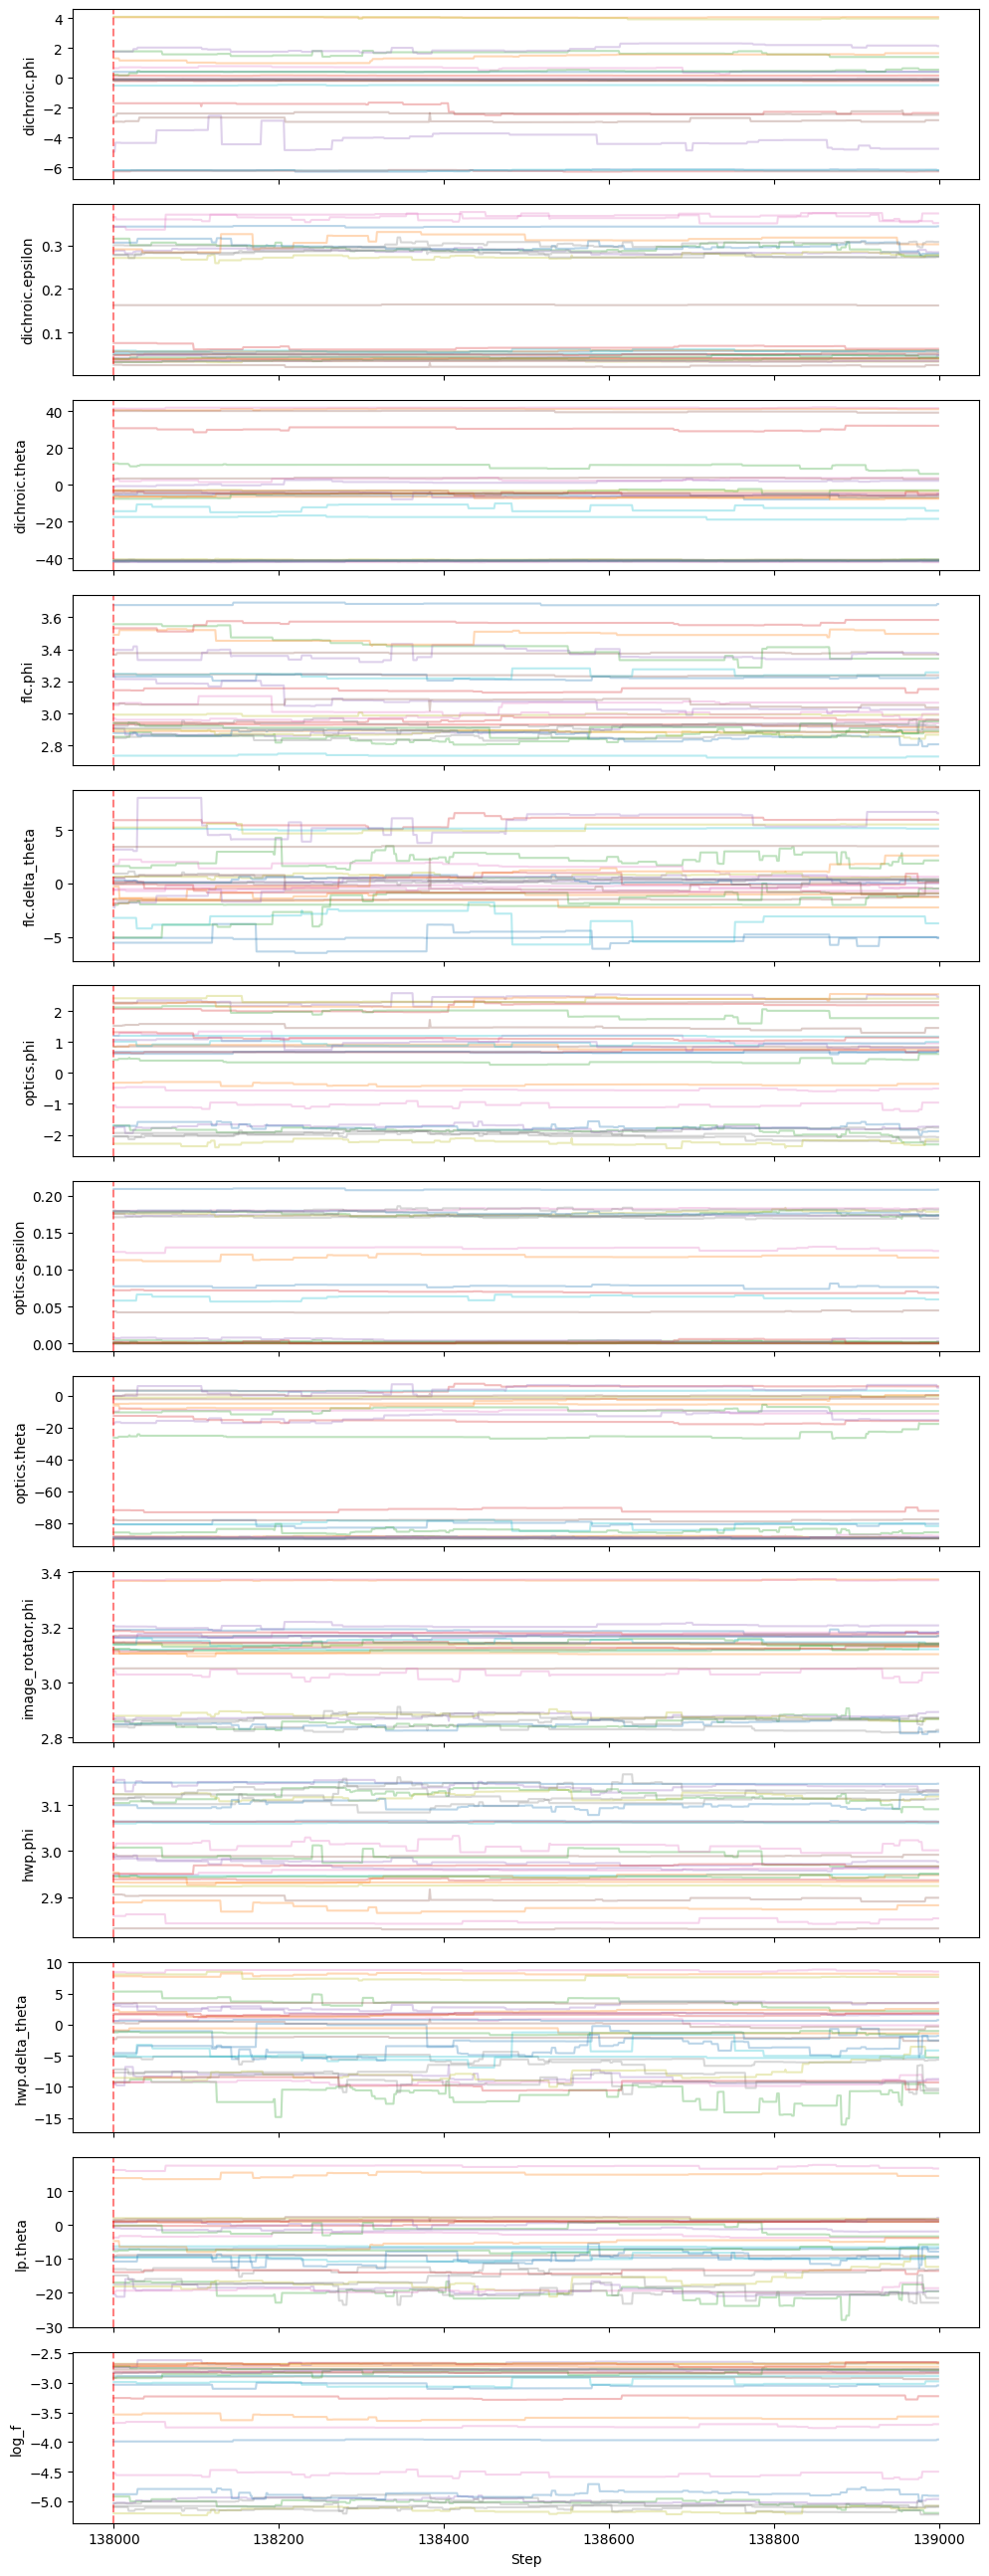

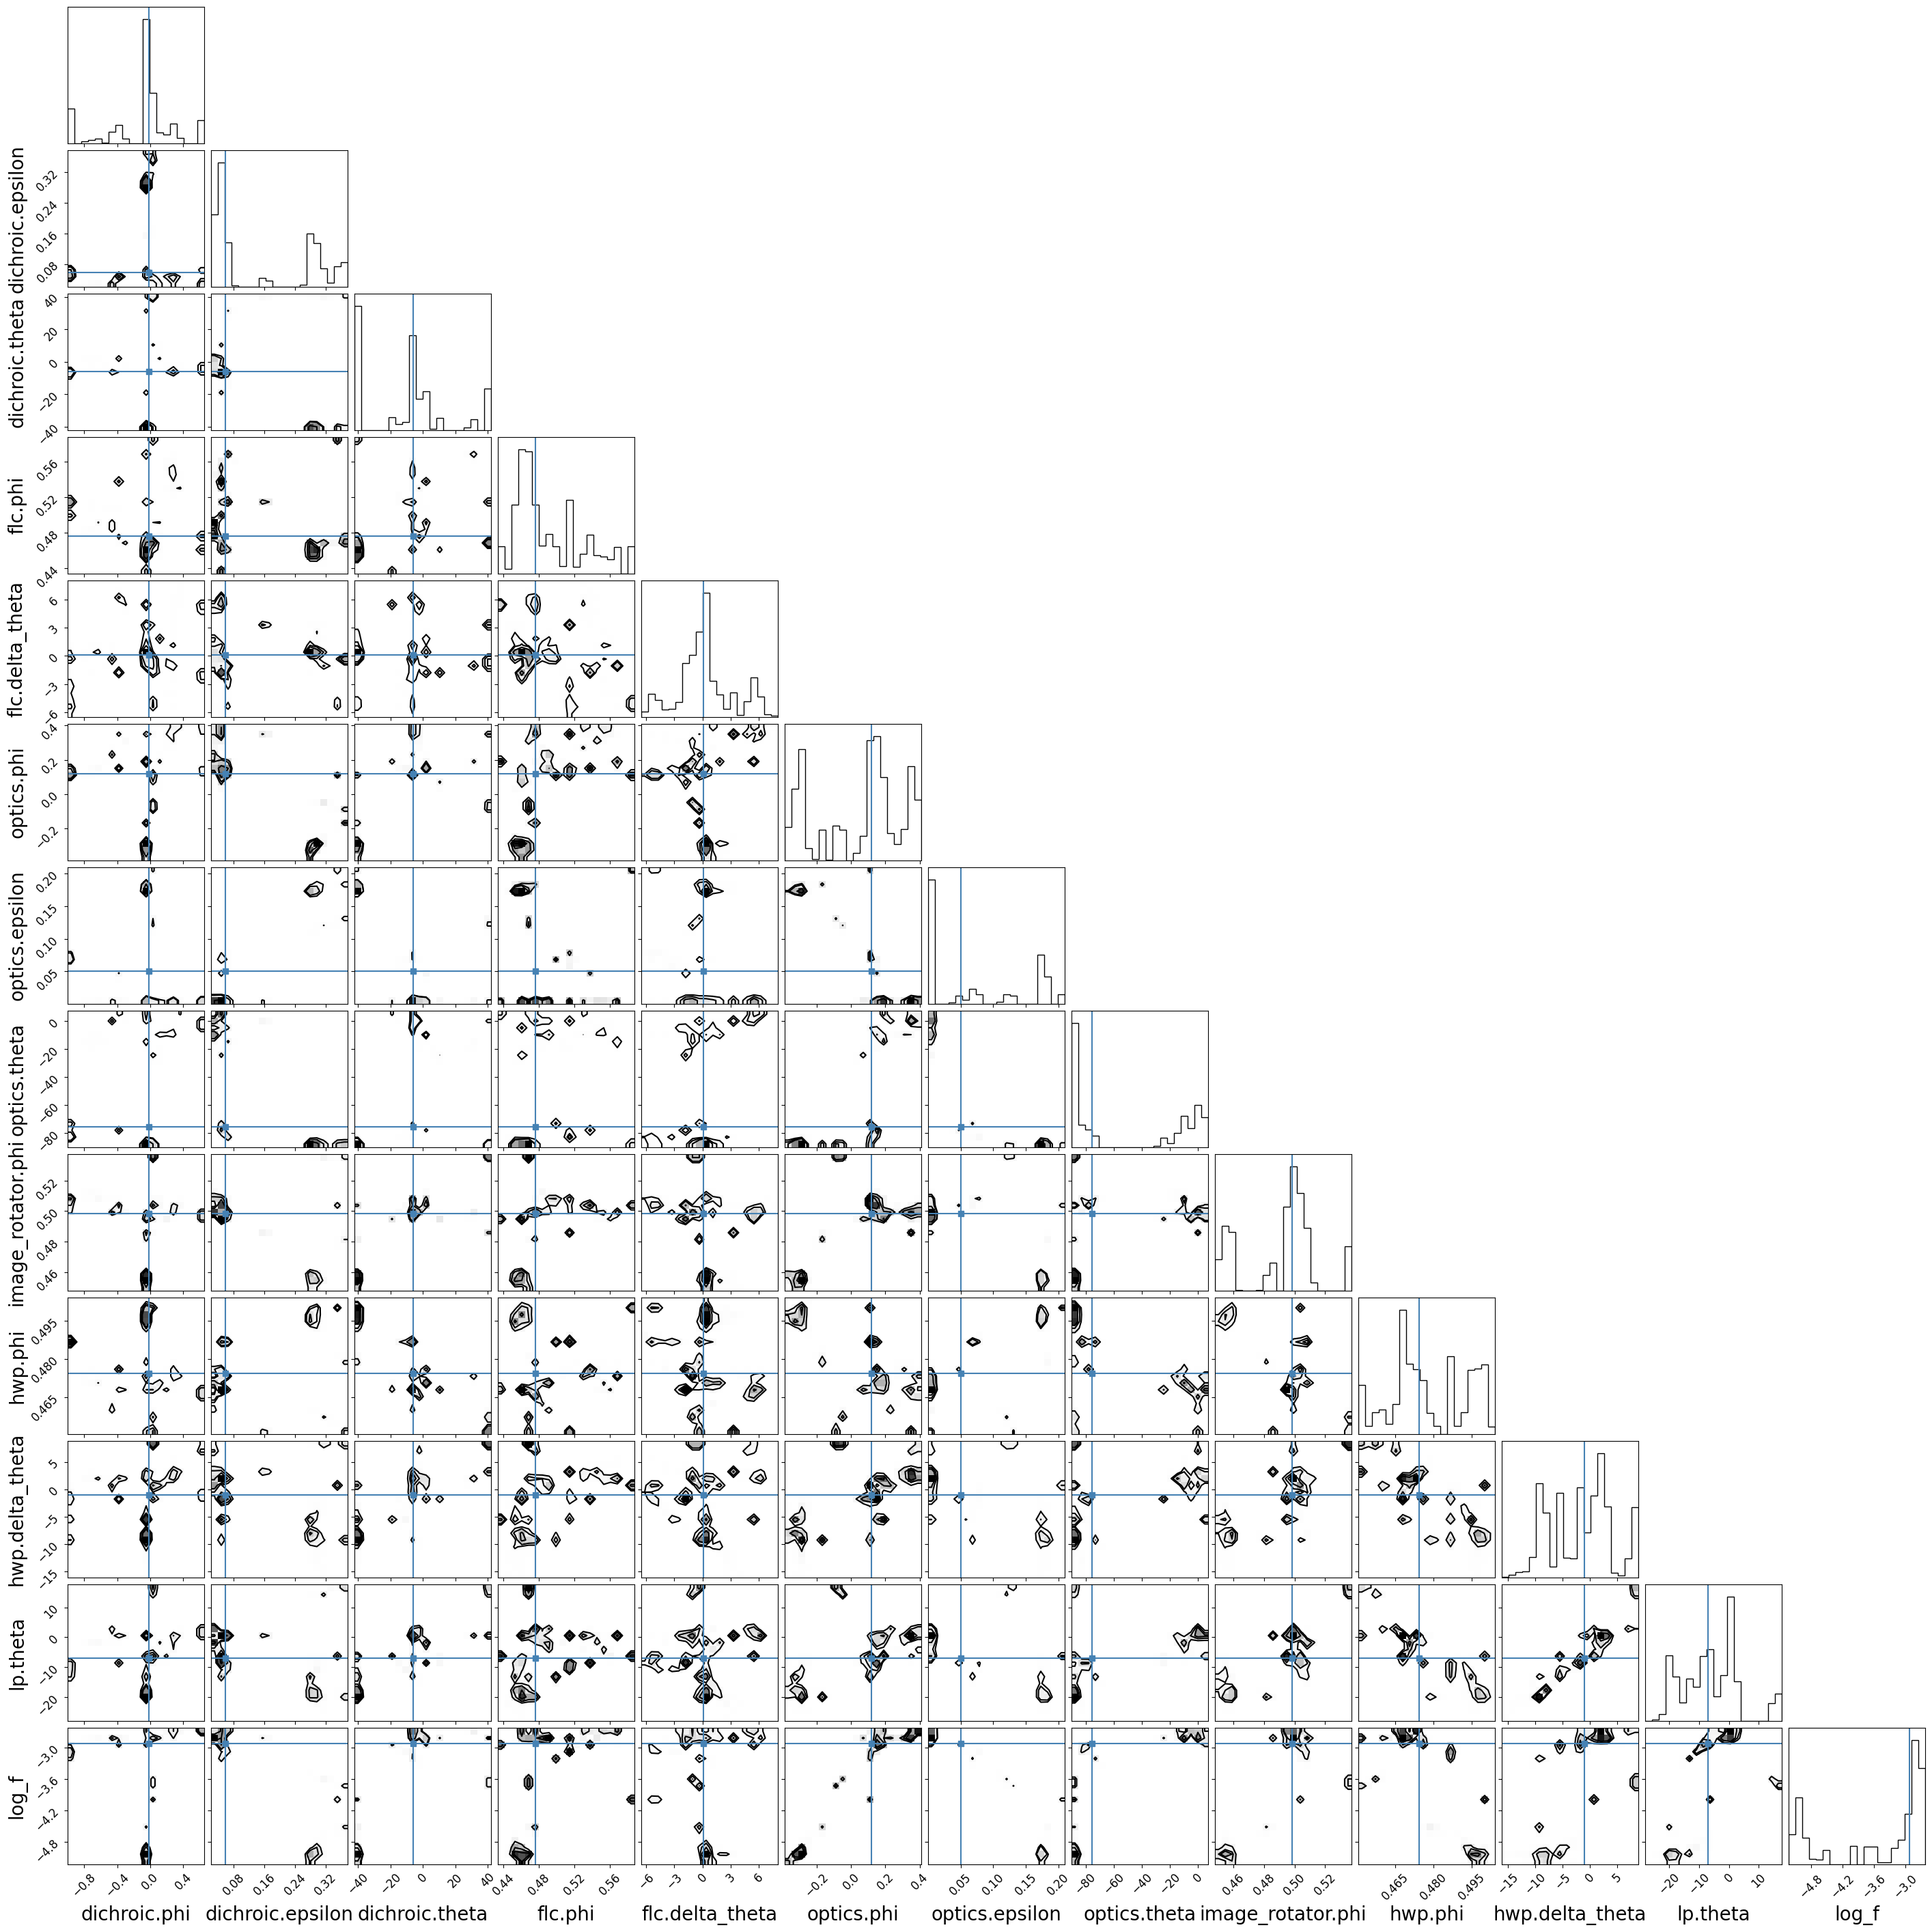

In [3]:
chain, names = plotting.load_chain_and_labels(h5_file_path, txt_file_path, include_logf = True, copy_file=True)
chain_step_range = (138000, 139000)
corner_plot_step_range = (138000, 139000)

# Print median ± std for each parameter
plotting.summarize_posteriors(chain, names, system_dict, step_range=corner_plot_step_range, 
    txt_save_file_path = txt_save_file_path, txt_file_path = txt_file_path)

# Check chain shape after loading
print("Chain shape (nsteps, nwalkers, ndim):", chain.shape)

# Plot trace plots for MCMC chains
plotting.plot_trace(chain, names, step_range=chain_step_range, max_walkers=100)

# Plot corner plot from flattened chain
plotting.plot_corner_flat(chain, names, step_range=corner_plot_step_range)


## Step 2.5: Autocorrelation Time Diagnostics

In [4]:
import emcee

# Use the full loaded chain by default. Set a different range to estimate tau after burn-in.
autocorr_step_range = (0, None)
autocorr_thin = 1
autocorr_tol = 0  # Use 50 for emcee's usual convergence check; 0 always returns an estimate.

act_start, act_end = autocorr_step_range
if act_end is None:
    act_end = chain.shape[0]

if act_start < 0 or act_end > chain.shape[0] or act_start >= act_end:
    raise ValueError(f"Invalid autocorr_step_range {autocorr_step_range} for chain with {chain.shape[0]} steps.")

act_chain = chain[act_start:act_end:autocorr_thin, :, :]
if act_chain.shape[0] < 2:
    raise ValueError("Autocorrelation calculation needs at least two saved steps.")

autocorr_tau = emcee.autocorr.integrated_time(act_chain, tol=autocorr_tol, quiet=True)
autocorr_tau_steps = autocorr_tau * autocorr_thin
autocorr_nsteps = act_end - act_start
autocorr_neff = act_chain.shape[0] * act_chain.shape[1] / autocorr_tau
recommended_burn_in = int(2 * np.max(autocorr_tau_steps))
recommended_thinning = max(1, int(0.5 * np.min(autocorr_tau_steps)))

print(f"Autocorrelation step range: {act_start} to {act_end} (thin={autocorr_thin})")
print(f"{'parameter':<35} {'tau [steps]':>12} {'nsteps/tau':>12} {'N_eff':>12}")
for name, tau_steps, neff in zip(names, autocorr_tau_steps, autocorr_neff):
    print(f"{name:<35} {tau_steps:12.1f} {autocorr_nsteps / tau_steps:12.1f} {neff:12.0f}")

print(f"Mean tau: {np.mean(autocorr_tau_steps):.1f} steps")
print(f"Max tau: {np.max(autocorr_tau_steps):.1f} steps")
print(f"Recommended burn-in: {recommended_burn_in} steps")
print(f"Recommended thinning: {recommended_thinning} steps")


Autocorrelation step range: 0 to 142000 (thin=1)
parameter                            tau [steps]   nsteps/tau        N_eff
dichroic.phi                             11145.4         12.7          357
dichroic.epsilon                         14046.3         10.1          283
dichroic.theta                           15416.3          9.2          258
flc.phi                                  12847.2         11.1          309
flc.delta_theta                          10081.9         14.1          394
optics.phi                               15846.1          9.0          251
optics.epsilon                           15090.8          9.4          263
optics.theta                             15062.7          9.4          264
image_rotator.phi                        14021.8         10.1          284
hwp.phi                                  14643.2          9.7          272
hwp.delta_theta                          13314.5         10.7          299
lp.theta                                 14933.4   

# Step 2.6: Apply Recommended Burn-in and Thinning


Using burn-in = 33913 saved steps and thinning = 5040 saved steps.
Posterior chain shape (nthinned_steps, nwalkers, ndim): (22, 28, 13)
Original saved steps included: 33913 to 139753 (22 thinned samples per walker).
dichroic.phi (waves): -0.02085 ± 0.42284
dichroic.epsilon (): 0.05647 ± 0.12568
dichroic.theta (): -5.58304 ± 25.54980
flc.phi (waves): 0.49263 ± 0.04012
flc.delta_theta (): 0.16498 ± 3.88006
optics.phi (waves): 0.12044 ± 0.20774
optics.epsilon (): 0.03254 ± 0.07849
optics.theta (): -74.88551 ± 39.80100
image_rotator.phi (waves): 0.50008 ± 0.01907
hwp.phi (waves): 0.47365 ± 0.01224
hwp.delta_theta (): 0.08564 ± 5.15719
lp.theta (): -4.26687 ± 7.96607
log_f (): -2.85488 ± 0.81825


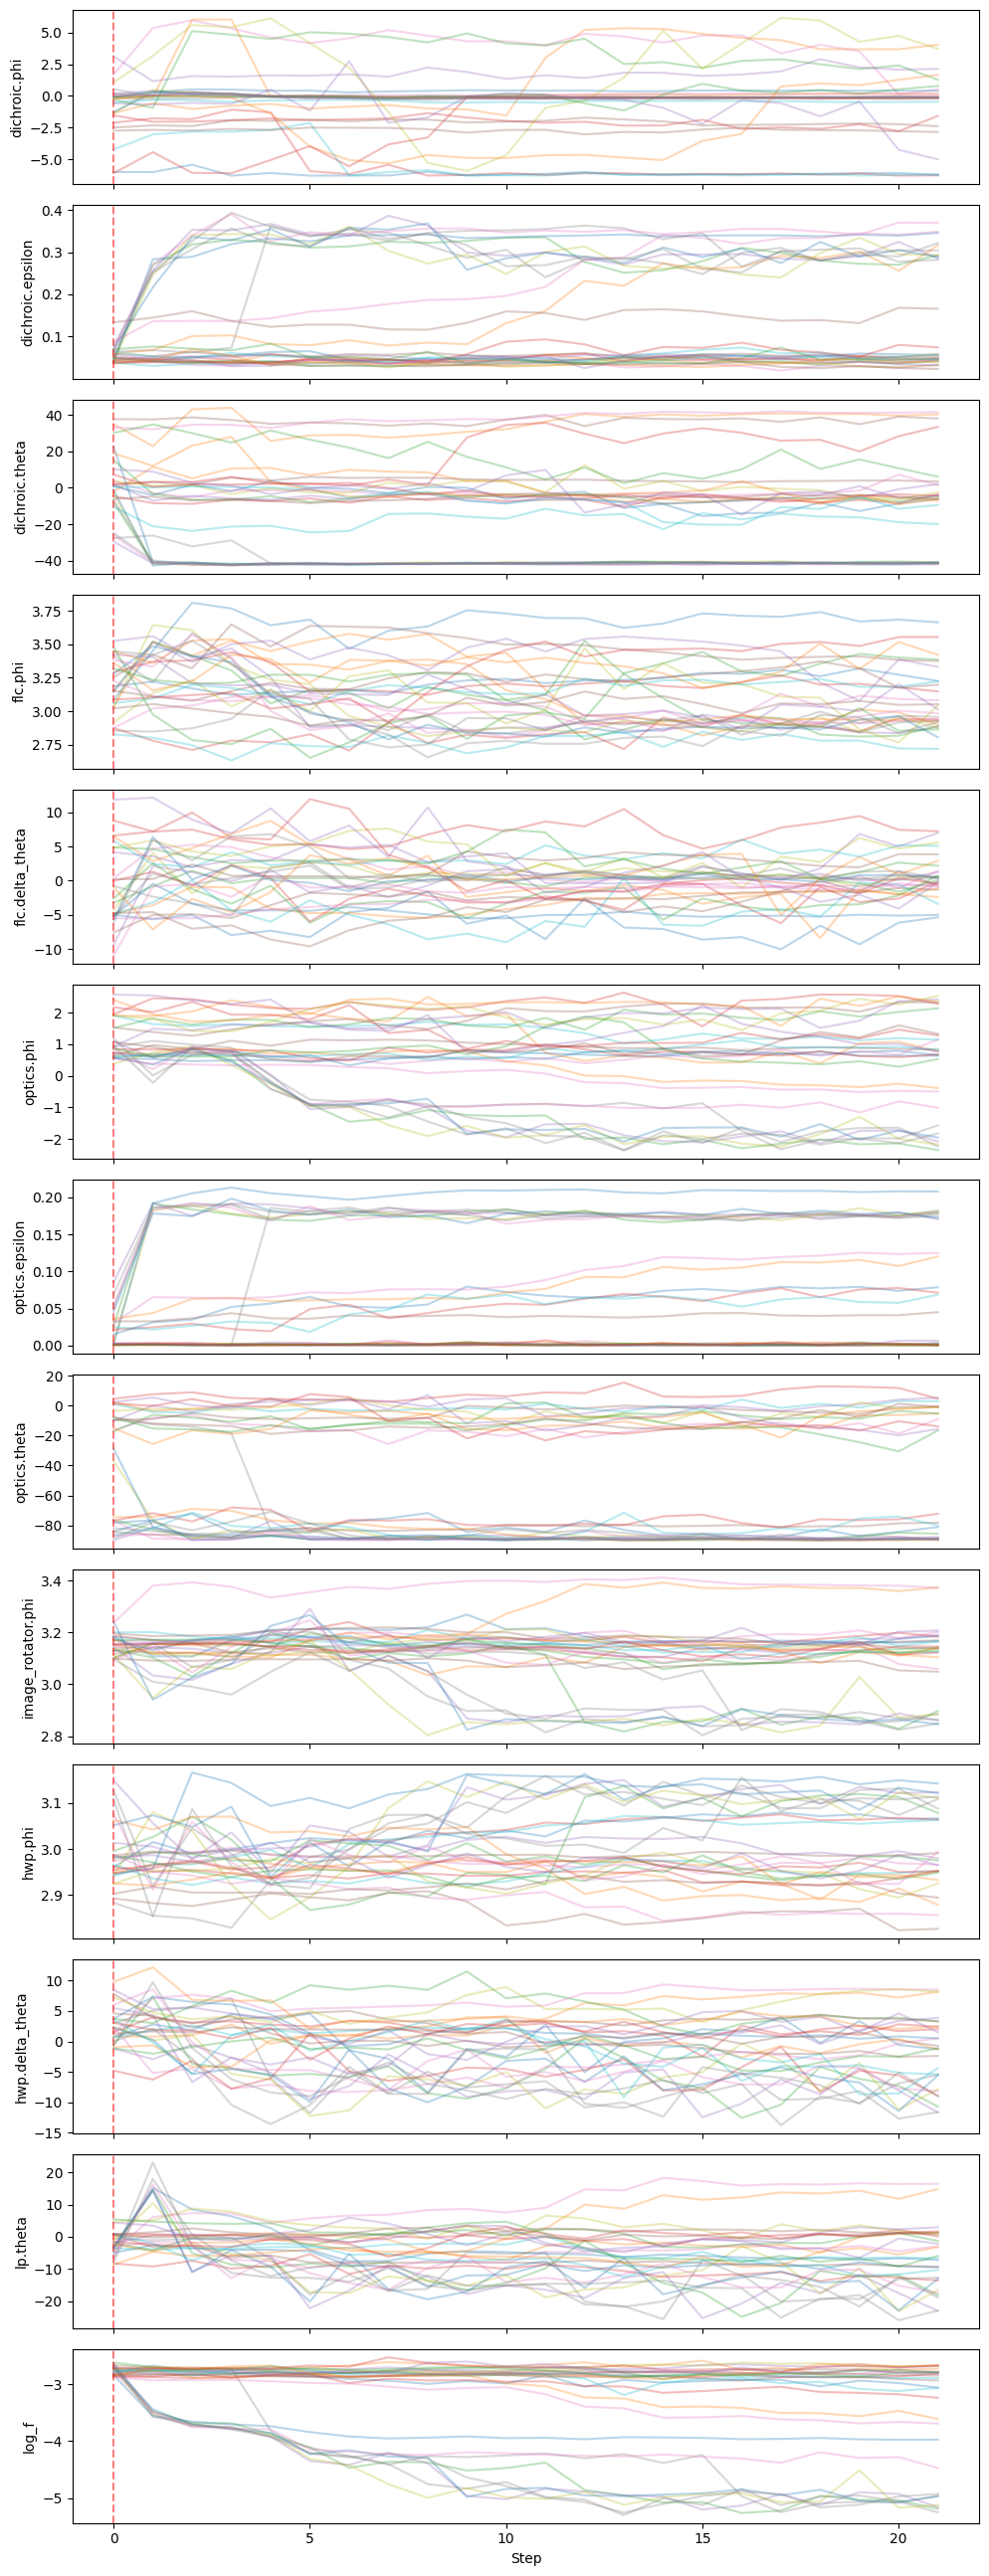

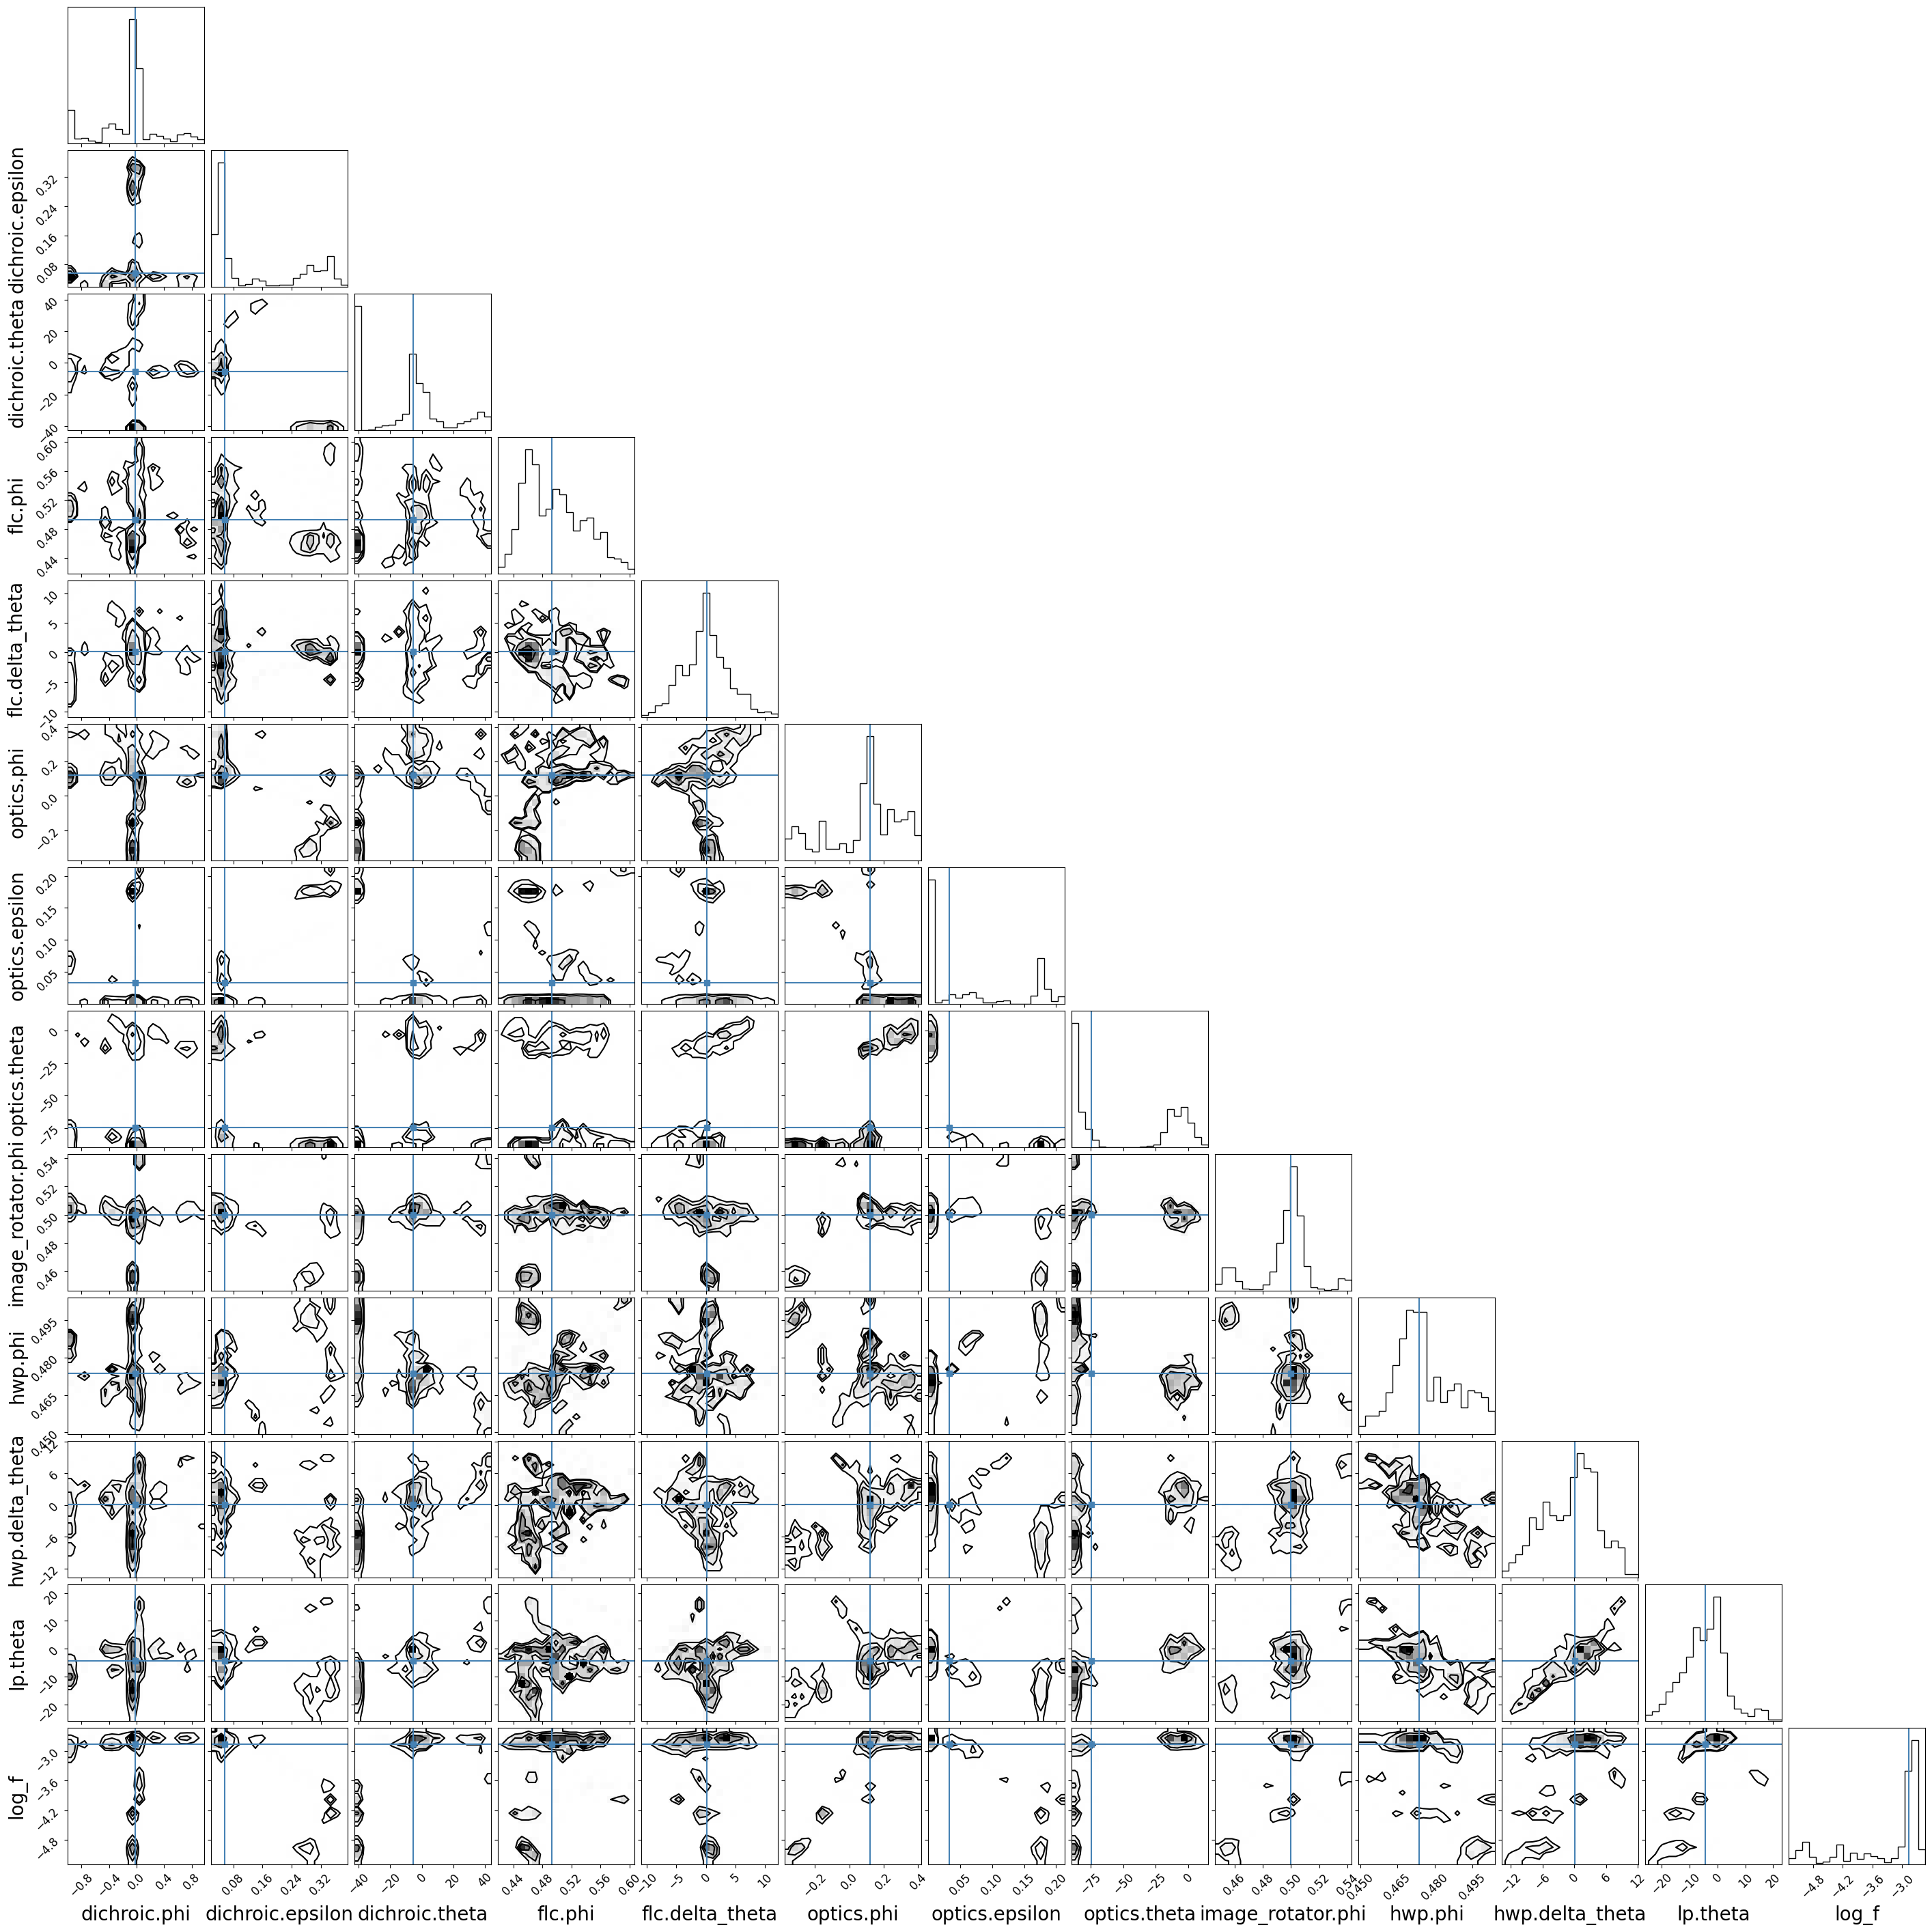

In [5]:
burn_in = recommended_burn_in
thinning = recommended_thinning

if burn_in < 0 or burn_in >= chain.shape[0]:
    raise ValueError(f"Invalid burn_in {burn_in} for chain with {chain.shape[0]} steps.")
if thinning < 1:
    raise ValueError(f"Invalid thinning {thinning}; thinning must be >= 1.")

posterior_chain = chain[burn_in::thinning, :, :]
posterior_step_numbers = np.arange(burn_in, chain.shape[0], thinning)
if posterior_chain.shape[0] < 1:
    raise ValueError("No posterior samples remain after applying burn-in and thinning.")

chain_step_range = (0, None)
corner_plot_step_range = (0, None)

print(f"Using burn-in = {burn_in} saved steps and thinning = {thinning} saved steps.")
print("Posterior chain shape (nthinned_steps, nwalkers, ndim):", posterior_chain.shape)
print(
    f"Original saved steps included: {posterior_step_numbers[0]} to "
    f"{posterior_step_numbers[-1]} ({posterior_chain.shape[0]} thinned samples per walker)."
)

# Print posterior summary for the thinned chain and save the median-fit text file.
plotting.summarize_posteriors(
    posterior_chain,
    names,
    system_dict,
    step_range=corner_plot_step_range,
    txt_save_file_path=txt_save_file_path,
    txt_file_path=txt_file_path,
)

# Plot trace plots after burn-in/thinning.
plotting.plot_trace(posterior_chain, names, step_range=chain_step_range, max_walkers=100)

# Plot corner plot from the flattened thinned posterior chain.
plotting.plot_corner_flat(posterior_chain, names, step_range=corner_plot_step_range)


# Step 3: Plot median configuration of posteriors

In [6]:
file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"

interleaved_values, interleaved_stds, configuration_list = inst.read_csv(file_path, 
    obs_mode = obs_mode, obs_filter = wavelength_string)

In [7]:
# Loading in median parameters
with open(txt_save_file_path, "r") as f:
    past_fit = json.load(f)

# print(past_fit)

theta_pol = past_fit["lp"]["theta"]
delta_HWP = past_fit["hwp"]["phi"] 
offset_HWP = past_fit["hwp"]["delta_theta"]
delta_derot = past_fit["image_rotator"]["phi"] 
offset_derot = past_fit["image_rotator"].get("delta_theta", 0)
delta_opts = past_fit["optics"]["phi"]
epsilon_opts = past_fit["optics"]["epsilon"]
rot_opts = past_fit["optics"]["theta"]
delta_FLC = past_fit["flc"]["phi"] 
rot_FLC = past_fit["flc"]["delta_theta"]
delta_dichroic = past_fit["dichroic"]["phi"]
epsilon_dichroic = past_fit["dichroic"]["epsilon"]
rot_dichroic = past_fit["dichroic"]["theta"]

print(delta_HWP)

# NOTE: Components must be listed downstream to upstream
# Define the instrument configuration as a system dictionary

system_dict = {
    "components": {
        "wollaston": {
            "type": "wollaston_prism_function",
            "properties": {"beam": "o", "transmission_ratio": em_gain},
        },
        "dichroic": {
            "type": "diattenuator_retarder_function",
            "properties": {
                "phi": delta_dichroic * 2 * np.pi,
                "epsilon": epsilon_dichroic,
                "theta": rot_dichroic,
            },
        },
        "flc": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_FLC * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": rot_FLC,
            },
        },
        "optics": {
            "type": "diattenuator_retarder_function",
            "properties": {
                "phi": delta_opts * 2 * np.pi,
                "epsilon": epsilon_opts,
                "theta": rot_opts,
            },
        },
        "image_rotator": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_derot * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": offset_derot,
            },
        },
        "hwp": {
            "type": "general_retarder_function",
            "properties": {
                "phi": delta_HWP * 2 * np.pi,
                "theta": 0,  # not fitted
                "delta_theta": offset_HWP,
            },
        },
        "lp": {
            "type": "general_linear_polarizer_function_with_theta",
            "properties": {"theta": theta_pol},
        },
    }
}

system_mm = inst.generate_system_mueller_matrix(system_dict)
print(system_mm.evaluate())


0.47365018293690353
[[ 0.48244843  0.47710709 -0.0715913   0.        ]
 [ 0.48244843  0.47710709 -0.0715913   0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]]


logl value: 10800.532138474175


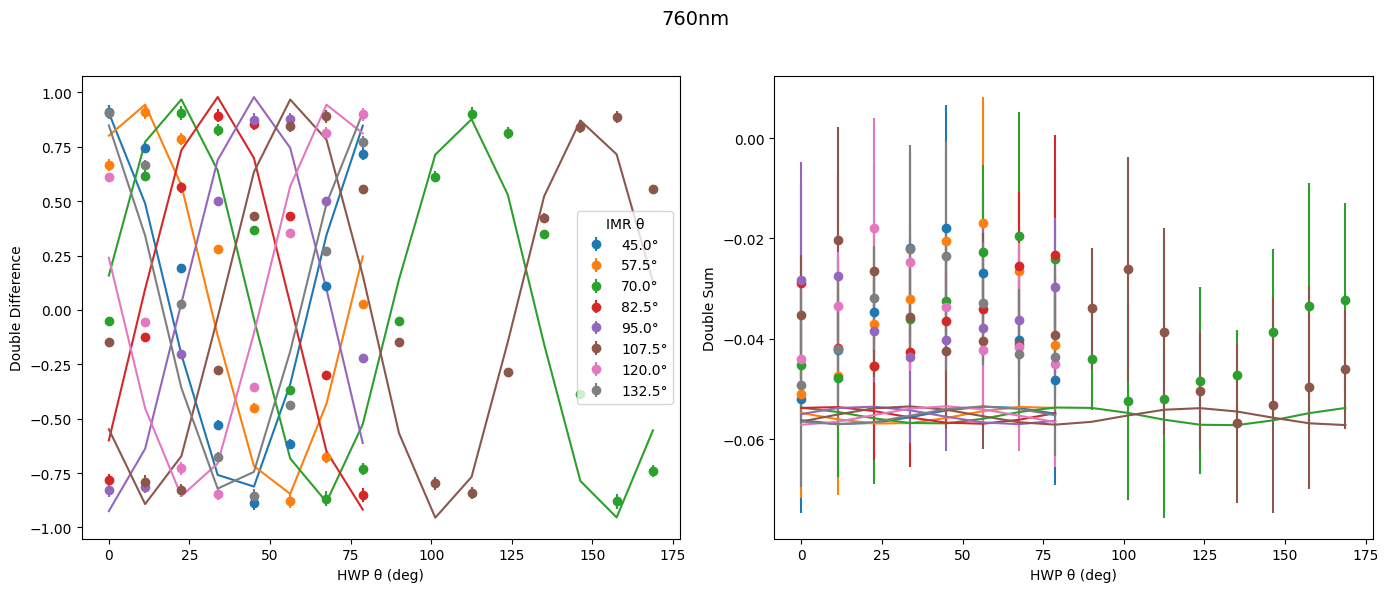

In [8]:
# Fittin for all parameters

p0 = {
    "wollaston": {"transmission_ratio": em_gain}, 
}

p0_values, p0_keywords = inst.parse_configuration(p0)
s_in = np.array([1, 0, 0, 0])
logl_value = inst.logl(p0_values, p0_keywords, system_mm, interleaved_values, interleaved_stds, configuration_list,
    s_in=s_in, logl_function=None, process_dataset=inst.process_dataset, process_errors=inst.process_errors, 
    process_model=inst.process_model)
print("logl value: " + str(logl_value))

# TODO: Add an initial plot block here
# Plotting intial plot
# updated_system_mm = inst.update_system_mm(p0_values, p0_keywords, system_mm)
model = inst.model(p0_values, p0_keywords, system_mm, configuration_list, 
    process_model = inst.process_model)

inst.plot_data_and_model(interleaved_values, interleaved_stds, model, 
    configuration_list, wavelength = wavelength_string)

# Step 4: Plotting Random Chains for Fitting (UNDER CONSTRUCTION)

Plotting 100 random chain samples from steps 0 to 142000.
Selected (step, walker) pairs:
[(62075, 8), (133522, 23), (95113, 3), (66273, 17), (63964, 4), (110529, 1), (21908, 24), (46266, 22), (23462, 5), (101879, 16), (25921, 15), (70685, 16), (61486, 19), (116830, 0), (52604, 23), (99023, 27), (118180, 16), (28608, 0), (126078, 8), (137385, 3), (32267, 9), (130997, 18), (126821, 15), (18191, 21), (22817, 17), (119241, 22), (112985, 20), (26904, 20), (107904, 10), (19844, 23), (34017, 5), (78749, 20), (99437, 8), (74758, 9), (77449, 15), (40942, 15), (128585, 0), (111618, 21), (91427, 4), (109033, 14), (13083, 2), (119520, 0), (77612, 0), (55021, 23), (62963, 19), (67549, 19), (89426, 5), (9644, 14), (108079, 13), (32220, 26), (92946, 24), (127528, 7), (96991, 27), (52062, 21), (63286, 21), (65737, 3), (131598, 3), (72876, 18), (104474, 15), (105558, 8), (57141, 22), (52652, 8), (109899, 1), (10840, 18), (90420, 4), (96914, 8), (117521, 22), (12203, 27), (39299, 7), (13806, 3), (137837

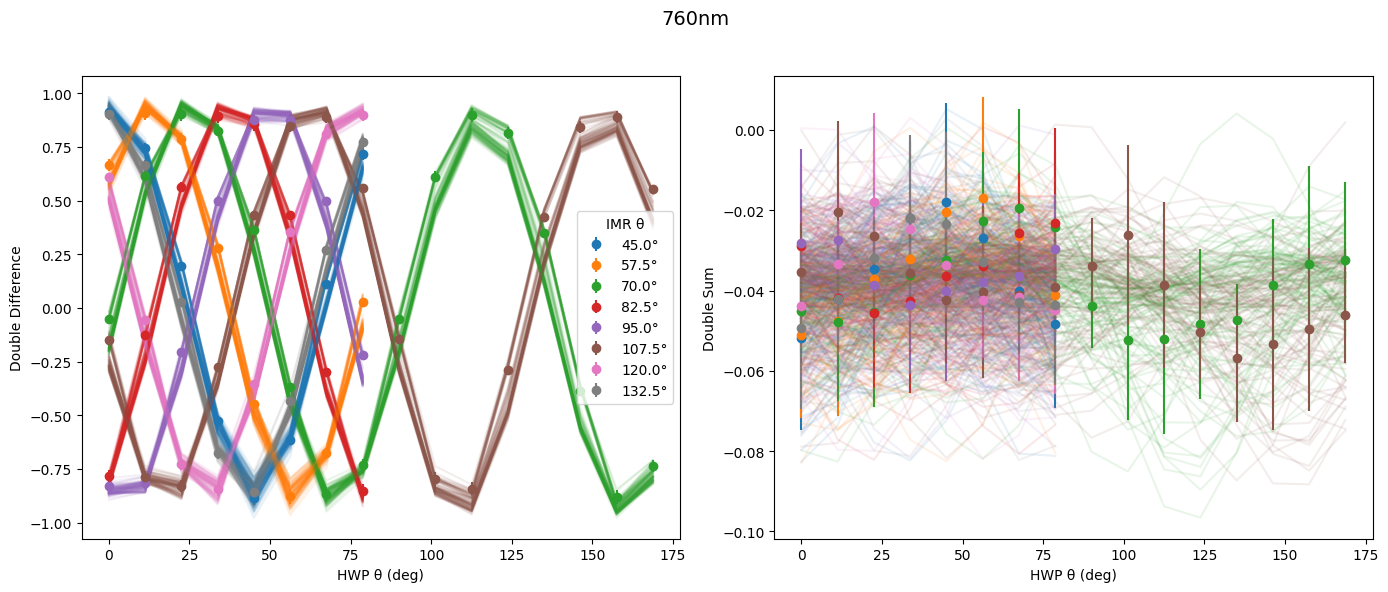

In [9]:
import importlib
inst = importlib.reload(inst)

# User settings
n_random_chains = 100
random_chain_step_range = corner_plot_step_range
random_chain_alpha = 0.1
random_seed = 42
imr_theta_filter = None

with open(txt_file_path, "r") as f:
    fit_param_dict = json.load(f)
_, fit_param_keys = inst.parse_configuration(fit_param_dict)

start, end = random_chain_step_range
if end is None:
    end = chain.shape[0]

if start < 0 or end > chain.shape[0] or start >= end:
    raise ValueError(f"Invalid random_chain_step_range {random_chain_step_range} for chain with {chain.shape[0]} steps.")

chain_window = chain[start:end, :, :]
flat_chain_window = chain_window.reshape(-1, chain.shape[-1])
n_available_samples = flat_chain_window.shape[0]

if chain.shape[-1] < len(fit_param_keys):
    raise ValueError(f"Chain has {chain.shape[-1]} parameters, but {len(fit_param_keys)} fitted parameters were found.")

if n_random_chains > n_available_samples:
    raise ValueError(f"Only {n_available_samples} samples available, but {n_random_chains} requested.")

rng = np.random.default_rng(random_seed)
selected_flat_indices = rng.choice(n_available_samples, size=n_random_chains, replace=False)
selected_steps = start + (selected_flat_indices // chain.shape[1])
selected_walkers = selected_flat_indices % chain.shape[1]
random_chain_samples = flat_chain_window[selected_flat_indices, :len(fit_param_keys)]
random_chain_system_mm = inst.generate_system_mueller_matrix(system_dict)
s_in_random = globals().get("s_in", np.array([1, 0, 0, 0]))

random_chain_models = [
    inst.model(
        sample,
        fit_param_keys,
        random_chain_system_mm,
        configuration_list,
        s_in=s_in_random,
        process_model=inst.process_model,
    )
    for sample in random_chain_samples
]

print(f"Plotting {n_random_chains} random chain samples from steps {start} to {end}.")
print("Selected (step, walker) pairs:")
print(list(zip(selected_steps.tolist(), selected_walkers.tolist())))

inst.plot_data_and_model(
    interleaved_values,
    interleaved_stds,
    random_chain_models,
    configuration_list,
    wavelength=wavelength_string,
    imr_theta_filter=imr_theta_filter,
    model_alpha=random_chain_alpha,
    first_model_alpha=random_chain_alpha,
)


In [10]:
# import sys
# import os

# # Add the directory containing instruments.py to the Python path
# custom_module_path = "/home/rebeccaz/Github/vampires_calibration"
# sys.path.append(custom_module_path)

# import plotting_rewrite as plotting
# import numpy as np

# all_step_range = (0, None)
# corner_plot_step_range = (24000, 25000)

# # Define the system configuration dictionary
# system_dict = {
#     "components": {
#         "wollaston": {
#             "type": "wollaston_prism_function",
#             "properties": {"beam": "o", "transmission_ratio": 1.18},
#         },
#         "dichroic": {
#             "type": "diattenuator_retarder_function",
#             "properties": {"phi": 0, "epsilon": 0, "theta": 0},
#         },
#         "flc": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
#         },
#         "optics": {
#             "type": "diattenuator_retarder_function",
#             "properties": {"phi": 0, "epsilon": 0, "theta": 0},
#         },
#         "image_rotator": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5 * 2 * np.pi, "theta": 0, "delta_theta": 0},
#         },
#         "hwp": {
#             "type": "general_retarder_function",
#             "properties": {"phi": 0.5, "theta": 0, "delta_theta": 0},
#         },
#         "lp": {
#             "type": "general_linear_polarizer_function_with_theta",
#             "properties": {"theta": 0},
#         },
#     }
# }

# # Input paths and call plotting function
# h5_filename = "675nm_no_IMR_offset_with_dichroic.h5"
# txt_filename = "675-50nm.txt"
# csv_file_path = "/home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table.csv"

# plotting.plot_mcmc_fits_double_diff_sum(
#     h5_filename=h5_filename,
#     txt_filename=txt_filename,
#     csv_path=csv_file_path,
#     filter_wavelength="675-50",
#     system_dict=system_dict,
#     wavelength_str="675nm",
#     n_samples=50,
#     step_range = all_step_range
# )
